In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [9]:
iris = datasets.load_iris()
X = iris.data 
target = iris.target
Y = to_categorical(target).astype("uint8")

In [10]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 50
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 100
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]
[7.  3.2 4.7 1.4]
1
[0 1 0]
[6.3 3.3 6.  2.5]
2
[0 0 1]


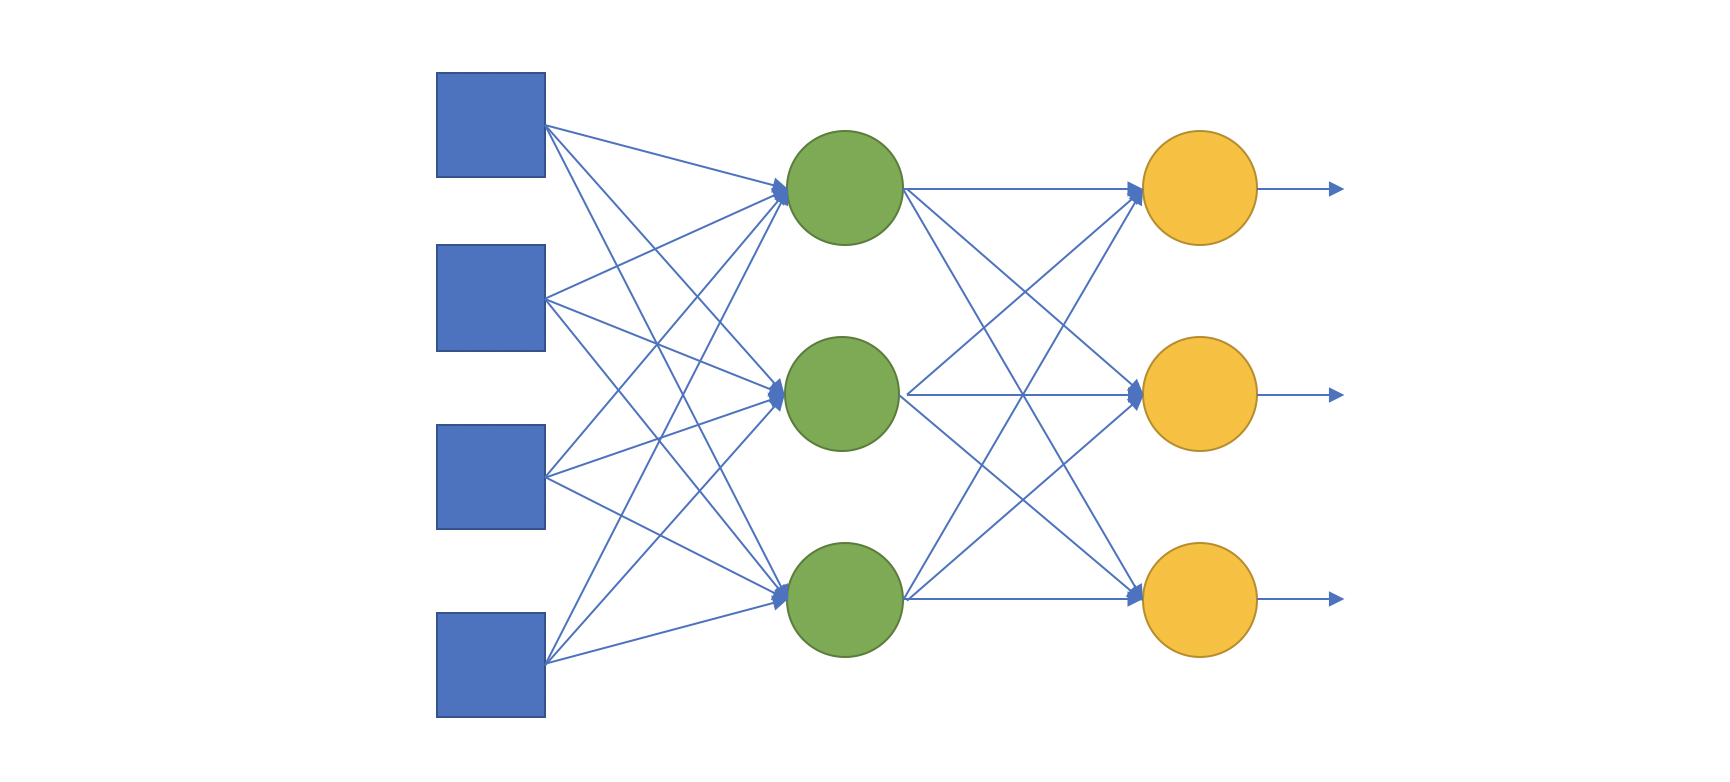

In [11]:
#Topology: 4 x 3 x 3
input_size_layer1 = 4
num_neurons_layer1 = 3

input_size_layer2 = num_neurons_layer1
num_neurons_layer2 = 3

layer1 = list()
layer2 = list()

In [12]:
def generate_weights(num_weights):
  w = np.zeros(num_weights)
  for i in range(len(w)):
    w[i] = (np.random.rand(1) - 0.5)
  return w

def init_weights():
  layer1.clear()
  layer2.clear()
  for i in range(num_neurons_layer1):
    layer1.append( generate_weights(input_size_layer1+1)) # plus 1 -> plus bias
  for i in range(num_neurons_layer2):
    layer2.append( generate_weights(input_size_layer2+1)) # plus 1 -> plus bias

def net_input(input_vector, w):
  net_input_var = w[0]
  for i in range(len(input_vector)):
    net_input_var += w[i+1] * input_vector[i]
  return net_input_var

def sigmoid(z):
  activation = 1/(1+np.power(np.e, -z))
  return activation

def propagate(X, w):
  neuronInput = net_input(X, w) # Sigma
  neuronOutput = sigmoid(neuronInput) # sigma
  return neuronOutput

def calculate_error():
  total_err = 0
  for idx in range(len(X)):
    output_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(output_layer1)):
      output_layer1[i] = propagate(X[idx], layer1[i])

    output_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(output_layer2)):
      output_layer2[i] = propagate(output_layer1, layer2[i])
    
    err = Y[idx] - output_layer2
    err = np.power(err,2)
    err = err.sum()
    total_err += err

  return total_err / ( len(X) )

In [13]:
print(generate_weights(5))

[ 0.36304208  0.37779866  0.18465165  0.28270221 -0.30838232]


/var/folders/q8/1mz_tyzs0l97fh18rhtfz2v40000gn/T/ipykernel_63274/452928905.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w[i] = (np.random.rand(1) - 0.5)


/var/folders/q8/1mz_tyzs0l97fh18rhtfz2v40000gn/T/ipykernel_63274/452928905.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w[i] = (np.random.rand(1) - 0.5)


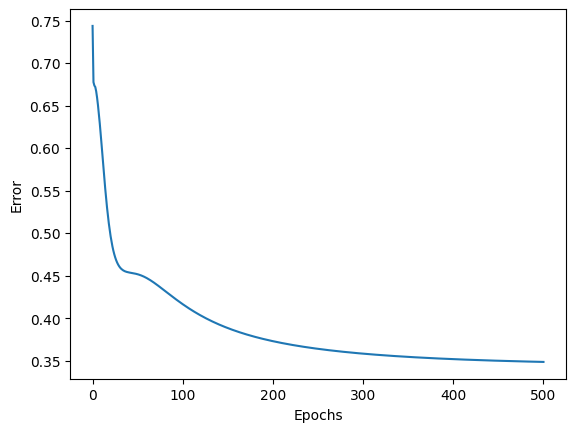

In [14]:
alpha = 0.03
epochs = 500

init_weights()

E = list()
E.append( calculate_error() )
for e in range(epochs):
  for d in range(len(X)):
    # Etapa 1 - Propagación
    output_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(output_layer1)):
      output_layer1[i] = propagate(X[d], layer1[i])

    output_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(output_layer2)):
      output_layer2[i] = propagate(output_layer1, layer2[i])

    # Etapa 2 - Retropropagación de los errores
    delta_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(delta_layer2)):
      delta_layer2[i] = output_layer2[i] * (1 - output_layer2[i]) * (Y[d][i] - output_layer2[i])

    for i in range(len(layer2)):
      layer2[i][0] += alpha * delta_layer2[i] * 1
      for j in range(len(layer2[i])-1):
        layer2[i][j+1] += alpha * delta_layer2[i] * output_layer1[j]

    delta_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(delta_layer1)):
      weighted_delta_errors = 0
      for j in range(num_neurons_layer2):
        weighted_delta_errors += layer2[i][j+1] * delta_layer2[j]
      delta_layer1[i] = output_layer1[i] * (1 - output_layer1[i]) * weighted_delta_errors

    for i in range(len(layer1)):
      layer1[i][0] += alpha * delta_layer1[i] * 1
      for j in range(len(layer1[i])-1):
        layer1[i][j+1] += alpha * delta_layer1[i] * X[d][j]

  E.append( calculate_error() )

Error_vec = np.asarray(E)
plt.plot(Error_vec)
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()